<a href="https://colab.research.google.com/github/collab-shubhamshekhar/BringYourOwnProject/blob/main/Cloud_Resource_Allocation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
## Create Cloud Environment
class CloudEnv:
    def __init__(self):
        self.max_cpu = 100
        self.reset()

    def reset(self):
        self.available_cpu = self.max_cpu
        self.queue = [random.randint(5, 30) for _ in range(5)]  # task sizes
        return self._get_state()

    def _get_state(self):
        return (self.available_cpu, len(self.queue))

    def step(self, action):
        # actions: 0=low, 1=medium, 2=high allocation
        allocation = [10, 30, 50][action]

        reward = 0

        if len(self.queue) > 0 and self.available_cpu >= allocation:
            task = self.queue.pop(0)
            self.available_cpu -= allocation

            # reward: faster completion better
            reward += (allocation - task)

        else:
            reward -= 10  # penalty

        # simulate new incoming task
        if random.random() < 0.7:
            self.queue.append(random.randint(5, 30))

        # recover CPU
        self.available_cpu = min(self.max_cpu, self.available_cpu + 20)

        next_state = self._get_state()

        return next_state, reward

In [ ]:
## Q-Agent
class QAgent:
    def __init__(self):
        self.q_table = {}
        self.alpha = 0.1
        self.gamma = 0.9
        self.epsilon = 1.0

    def get_q(self, state):
        if state not in self.q_table:
            self.q_table[state] = [0, 0, 0]
        return self.q_table[state]

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 2)
        return np.argmax(self.get_q(state))

    def learn(self, state, action, reward, next_state):
        q_values = self.get_q(state)
        next_q = max(self.get_q(next_state))

        q_values[action] += self.alpha * (reward + self.gamma * next_q - q_values[action])

In [ ]:
## Training Loop
env = CloudEnv()
agent = QAgent()

episodes = 500
rewards = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    for _ in range(50):  # steps per episode
        action = agent.choose_action(state)
        next_state, reward = env.step(action)

        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.epsilon *= 0.995  # reduce exploration
    rewards.append(total_reward)

    if ep % 50 == 0:
        print(f"Episode {ep}, Reward: {total_reward}")

Episode 0, Reward: 297
Episode 50, Reward: 220
Episode 100, Reward: 287
Episode 150, Reward: 266
Episode 200, Reward: 242
Episode 250, Reward: 252
Episode 300, Reward: 289
Episode 350, Reward: 337
Episode 400, Reward: 322
Episode 450, Reward: 308


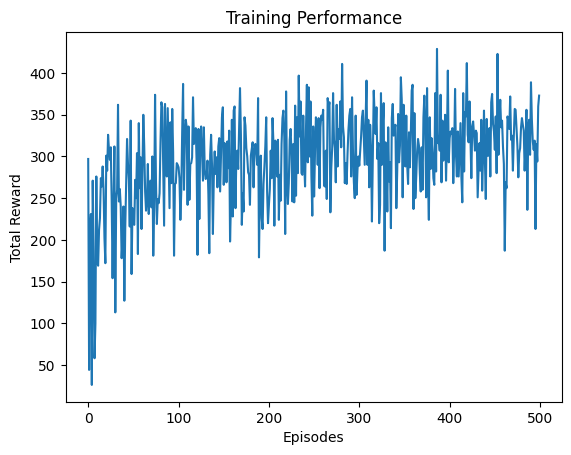

In [ ]:
## Vizualization
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Performance")
plt.show()

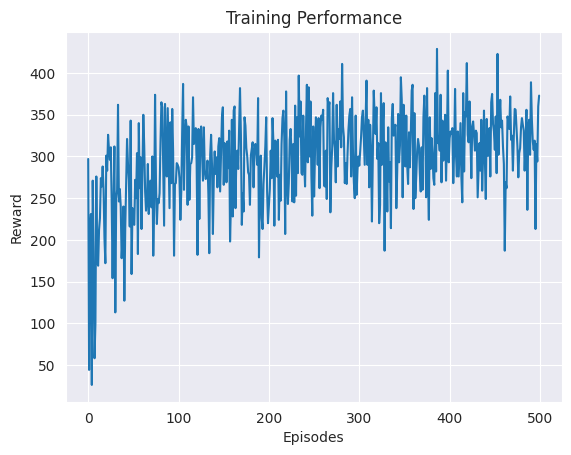

In [ ]:
import seaborn as sns
sns.set_style("darkgrid")

sns.lineplot(x=range(len(rewards)), y=rewards)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Training Performance")
plt.show()

In [ ]:
## Base Comparison
# Add priority: high priority tasks give extra reward
def random_policy(env):
    state = env.reset()
    total_reward = 0

    for _ in range(50):
        action = random.randint(0, 2)
        state, reward = env.step(action)
        total_reward += reward

    return total_reward

baseline = [random_policy(CloudEnv()) for _ in range(100)]

print("RL Avg Reward:", np.mean(rewards[-50:]))
print("Random Avg Reward:", np.mean(baseline))

RL Avg Reward: 320.4
Random Avg Reward: 227.06
